In [1]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from PIL import Image
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

In [2]:
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATASET_PATH = os.path.join(BASE_PATH, "data", "raw")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
data = []

for brand in os.listdir(DATASET_PATH):
    brand_path = os.path.join(DATASET_PATH, brand, "genuine")

    if not os.path.exists(brand_path):
        continue

    for img_name in os.listdir(brand_path):
        data.append({
            "image_path": os.path.join(brand_path, img_name),
            "brand": brand
        })

print("Total genuine images:", len(data))

Total genuine images: 2000


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# Triplet Dataset
class TripletDataset(Dataset):
    def __init__(self, data, transform):
        self.data = data
        self.transform = transform

        self.brand_to_images = {}
        for item in data:
            b = item["brand"]
            if b not in self.brand_to_images:
                self.brand_to_images[b] = []
            self.brand_to_images[b].append(item)

        self.brands = list(self.brand_to_images.keys())

    def __len__(self):
        return len(self.data)

    def load_image(self, path):
        img = Image.open(path)
        return img.convert("RGB")

    def __getitem__(self, idx):
        anchor = self.data[idx]
        anchor_brand = anchor["brand"]

        pos = random.choice(self.brand_to_images[anchor_brand])

        neg_brand = random.choice(self.brands)
        while neg_brand == anchor_brand:
            neg_brand = random.choice(self.brands)

        neg = random.choice(self.brand_to_images[neg_brand])

        anchor_img = self.load_image(anchor["image_path"])
        pos_img = self.load_image(pos["image_path"])
        neg_img = self.load_image(neg["image_path"])

        if self.transform:
            anchor_img = self.transform(anchor_img)
            pos_img = self.transform(pos_img)
            neg_img = self.transform(neg_img)

        return anchor_img, pos_img, neg_img

In [6]:
# Dataloader
dataset = TripletDataset(data, transform)
train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

print("Dataset ready")

Dataset ready


In [7]:
class EmbeddingModel(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(pretrained=True)
        base.fc = nn.Identity()
        self.base = base

    def forward(self, x):
        x = self.base(x)
        return F.normalize(x, dim=1)

In [ ]:
model = EmbeddingModel().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.TripletMarginLoss(margin=1.0)

print("Model ready")

In [9]:
sample = dataset[0]
print("Sample loaded")

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for anchor, positive, negative in train_loader:
        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        optimizer.zero_grad()

        anchor_emb = model(anchor)
        pos_emb = model(positive)
        neg_emb = model(negative)

        loss = criterion(anchor_emb, pos_emb, neg_emb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss:.4f}")

Sample loaded
Epoch [1/10] Loss: 441.5234
Epoch [2/10] Loss: 433.9004
Epoch [3/10] Loss: 424.0273
Epoch [4/10] Loss: 425.2918
Epoch [5/10] Loss: 432.3797
Epoch [6/10] Loss: 424.8307
Epoch [7/10] Loss: 426.8025
Epoch [8/10] Loss: 427.8212
Epoch [9/10] Loss: 402.8639
Epoch [10/10] Loss: 392.6217


In [10]:
torch.save(model.state_dict(), "../models/triplet_model.pth")
print("Triplet model saved")

Triplet model saved


In [11]:
def build_feature_db(model, data):
    model.eval()
    features = []
    paths = []

    with torch.no_grad():
        for item in data:
            img = Image.open(item["image_path"]).convert("RGB")
            img_tensor = transform(img).unsqueeze(0).to(device)

            feat = model(img_tensor)
            features.append(feat.cpu())
            paths.append(item["image_path"])

    features = torch.cat(features)
    return features, paths


db_features, db_paths = build_feature_db(model, data)
db_features = db_features.to(device)

print("Feature DB ready:", db_features.shape)

Feature DB ready: torch.Size([2000, 2048])


In [14]:
labels = [item["brand"] for item in data]

OUTPUT_PATH = os.path.join(BASE_PATH, "outputs")
os.makedirs(OUTPUT_PATH, exist_ok=True)

torch.save({
    "features": db_features.cpu(),
    "paths": db_paths,
    "labels": labels
}, os.path.join(OUTPUT_PATH, "embeddings.pt"))

print("Embeddings saved successfully")

Embeddings saved successfully


In [20]:
def find_similar_triplet(query_image_path, top_k=5):
    image = Image.open(query_image_path).convert("RGB")
    img_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        query_feat = model(img_tensor)
# here
    distances = torch.cdist(query_feat, db_features).squeeze(0)

    similarities = 1 / (1 + distances)

    top_indices = torch.topk(similarities, top_k).indices

    plt.figure(figsize=(12, 3))

    for i, idx in enumerate(top_indices):
        img = Image.open(db_paths[idx]).convert("RGB")

        plt.subplot(1, top_k, i+1)
        plt.imshow(img)
        plt.title(f"{similarities[idx]:.2f}")
        plt.axis("off")

    plt.suptitle("Triplet Similarity Results")
    plt.show()

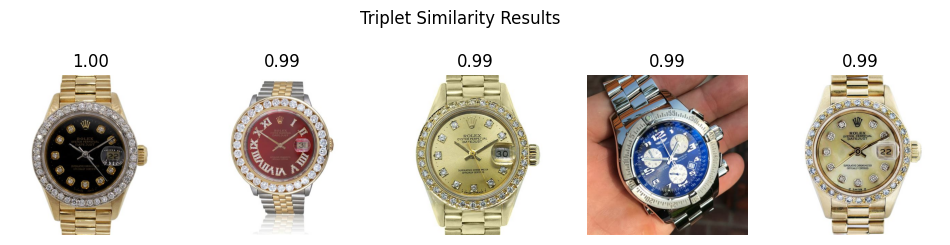

In [34]:
# Demo for similarity search
find_similar_triplet(
    "../data/raw/Rolex/genuine/050_d8c11f27.jpg"
)